<a href="https://colab.research.google.com/github/92kunheekim/tcrpmhc_pose_binding/blob/main/notebooks/pretrain_peptide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pretrain the MHC-conditioned peptide encoder (masked-residue, self-supervised)

Learns **allele-specific anchor motifs** by masking peptide residues and predicting
them from the unmasked residues **+ the class-I MHC**. Corpus = IEDB class-I
`(peptide, allele)` presentation pairs; each allele's groove is the **α1α2** sequence
(`mhc_classI_a1a2.json`), embedded with ESM-2.

Uses the **per-position TransformerEncoder** MLM (`arch='transformer'`) — predicts each
masked residue from its context + allele, so it learns anchors far better than a pooled
bottleneck. Saves `pep_state` + `mhc_state` that warm-start `PanFusion` (built with
`pep_arch='transformer'`). Clones the repo into `/content`, writes outputs into the repo,
commits & pushes. Run on Colab (GPU; ESM-2 needs `transformers`).

## Clone repo
Add your token in Colab **Secrets** (🔑) as `GITHUB_TOKEN`, then run.

In [1]:
import os, sys, subprocess
REPO = '/content/tcrpmhc_pose_binding'
REPO_URL = 'github.com/92kunheekim/tcrpmhc_pose_binding.git'
from google.colab import userdata
TOKEN = userdata.get('GITHUB_TOKEN')
if not os.path.isdir(REPO):
    subprocess.run(['git', 'clone', f'https://x-access-token:{TOKEN}@{REPO_URL}', REPO], check=True)
else:
    subprocess.run(['git', '-C', REPO, 'pull', '--ff-only'], check=True)   # refresh existing clone to latest main
os.chdir(REPO)
sys.path.insert(0, f'{REPO}/src')
DATA_DIR = f'{REPO}/data'
PRETRAIN_DIR = f'{REPO}/pretrained'; os.makedirs(PRETRAIN_DIR, exist_ok=True)
print('repo:', os.path.isdir(REPO), '| out:', PRETRAIN_DIR)


repo: True | out: /content/tcrpmhc_pose_binding/pretrained


In [2]:
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', f'{REPO}/requirements.txt'])
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'transformers'])
import json, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from pan_specific import (compute_esm_embeddings, peptide_pretrain_arrays,
                          pretrain_peptide_masked, masked_accuracy_breakdown, DEVICE)
from config import PEP_MAXLEN
print('device:', DEVICE)

device: cuda


## Config

In [6]:
PROC      = f'{DATA_DIR}/pmhc_classI_pretraining/processed'
IEDB_TSV  = f'{PROC}/iedb_mhc_classI_peptide_allele_unique.tsv'   # columns: peptide, allele, n_assays
A1A2_JSON = f'{PROC}/mhc_classI_a1a2.json'                        # allele -> alpha1+alpha2 groove seq
ESM_CACHE = f'{PROC}/esm_a1a2_cache.npz'                          # computed once, reused
ESM_MAXLEN = 190     # a1a2 groove is ~182 AA -> embed the full groove (no truncation)
PEP_MIN, PEP_MAX = 8, 11   # canonical class-I lengths
ARCH    = 'transformer'    # per-position MLM (recommended); 'pooled' = legacy bottleneck
EPOCHS  = 200
MASK_P  = 0.15
PATIENCE = 8

## 1. Load IEDB pairs + map allele -> α1α2 groove + ESM-2 (cache once)

In [4]:
a1a2 = json.load(open(A1A2_JSON))                                 # allele -> groove sequence
df = pd.read_csv(IEDB_TSV, sep='\t').dropna(subset=['peptide', 'allele'])
df = df[df.allele.isin(a1a2)]                                     # keep alleles with a groove seq
df = df[df.peptide.str.len().between(PEP_MIN, PEP_MAX)].reset_index(drop=True)
df['mhc_seq'] = df.allele.map(a1a2)                              # groove sequence as the MHC key
print(f'{len(df):,} (peptide, allele) pairs | {df.allele.nunique()} alleles')

uniq = sorted(df['mhc_seq'].unique())
if os.path.exists(ESM_CACHE):
    z = np.load(ESM_CACHE, allow_pickle=True); esm_table = {k: v for k, v in zip(z['seqs'], z['vecs'])}
else:
    esm_table = compute_esm_embeddings(uniq, maxlen=ESM_MAXLEN)   # frozen ESM-2 on the groove
    np.savez(ESM_CACHE, seqs=np.array(list(esm_table)), vecs=np.stack(list(esm_table.values())))
    print('cached ESM-2 ->', ESM_CACHE)

pep_seqs, mhc_esm = peptide_pretrain_arrays(df, esm_table, pep_col='peptide', mhc_col='mhc_seq')
alleles = df['allele'].to_numpy()                                 # aligned with pep_seqs

201,310 (peptide, allele) pairs | 197 alleles


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/534 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


cached ESM-2 -> /content/tcrpmhc_pose_binding/data/pmhc_classI_pretraining/processed/esm_a1a2_cache.npz


## 2. Masked-residue pretraining (per-position transformer MLM)

In [7]:
pep_state, mhc_state, hist, model = pretrain_peptide_masked(
    pep_seqs, mhc_esm, arch=ARCH, mask_p=MASK_P, epochs=EPOCHS, patience=PATIENCE,
    return_history=True, return_model=True, log=True)
torch.save(pep_state, f'{PRETRAIN_DIR}/pep_encoder_masked.pt')
torch.save(mhc_state, f'{PRETRAIN_DIR}/mhc_encoder_masked.pt')
hist.to_csv(f'{PRETRAIN_DIR}/pep_pretrain_history.csv', index=False)
hist.tail()

[pep-mask:transformer] ep   1  loss 2.8550  masked_acc 0.127
[pep-mask:transformer] ep   2  loss 2.8013  masked_acc 0.143
[pep-mask:transformer] ep   3  loss 2.7698  masked_acc 0.151
[pep-mask:transformer] ep   4  loss 2.7546  masked_acc 0.156
[pep-mask:transformer] ep   5  loss 2.7394  masked_acc 0.163
[pep-mask:transformer] ep   6  loss 2.7295  masked_acc 0.166
[pep-mask:transformer] ep   7  loss 2.7266  masked_acc 0.167
[pep-mask:transformer] ep   8  loss 2.7222  masked_acc 0.167
[pep-mask:transformer] ep   9  loss 2.7184  masked_acc 0.169
[pep-mask:transformer] ep  10  loss 2.7128  masked_acc 0.171
[pep-mask:transformer] ep  11  loss 2.7089  masked_acc 0.172
[pep-mask:transformer] ep  12  loss 2.7084  masked_acc 0.172
[pep-mask:transformer] ep  13  loss 2.7067  masked_acc 0.173
[pep-mask:transformer] ep  14  loss 2.7052  masked_acc 0.173
[pep-mask:transformer] ep  15  loss 2.7038  masked_acc 0.174
[pep-mask:transformer] ep  16  loss 2.7028  masked_acc 0.173
[pep-mask:transformer] e

,epoch,loss,masked_acc
64,65,2.677309,0.179914
65,66,2.673880,0.181018
66,67,2.674958,0.181623
67,68,2.675174,0.180921
68,69,2.675374,0.180362


## 3. Training curves

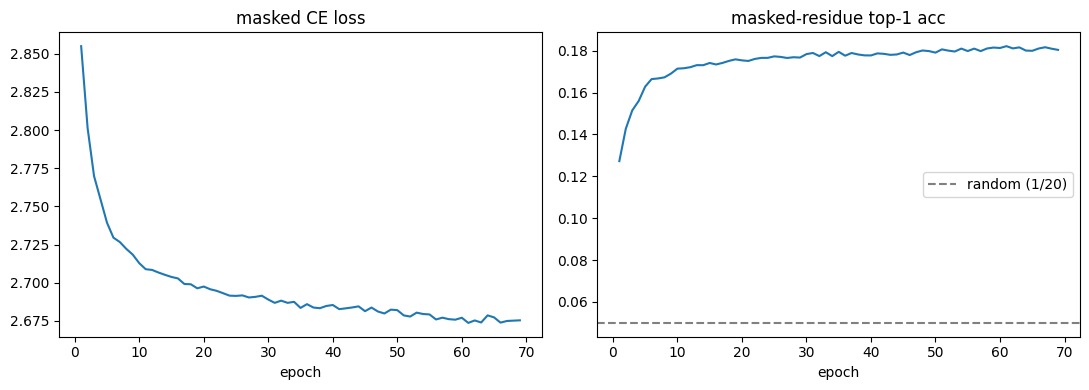

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist.epoch, hist.loss)
ax[0].set(title='masked CE loss', xlabel='epoch')
ax[1].plot(hist.epoch, hist.masked_acc)
ax[1].set(title='masked-residue top-1 acc', xlabel='epoch')
ax[1].axhline(1/20, ls='--', c='gray', label='random (1/20)')
ax[1].legend()
plt.tight_layout()
plt.savefig(f'{PRETRAIN_DIR}/pep_pretrain_curves.png', dpi=150)
plt.show()

## 3b. Per-position & per-allele accuracy (the real success check)

The overall ~20% average is dominated by high-entropy non-anchor positions. What matters
is whether accuracy **spikes at the anchors** (P2 and the C-terminal P-Omega) and varies
sensibly across alleles — that confirms the model learned presentation motifs, not just
amino-acid frequencies.

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


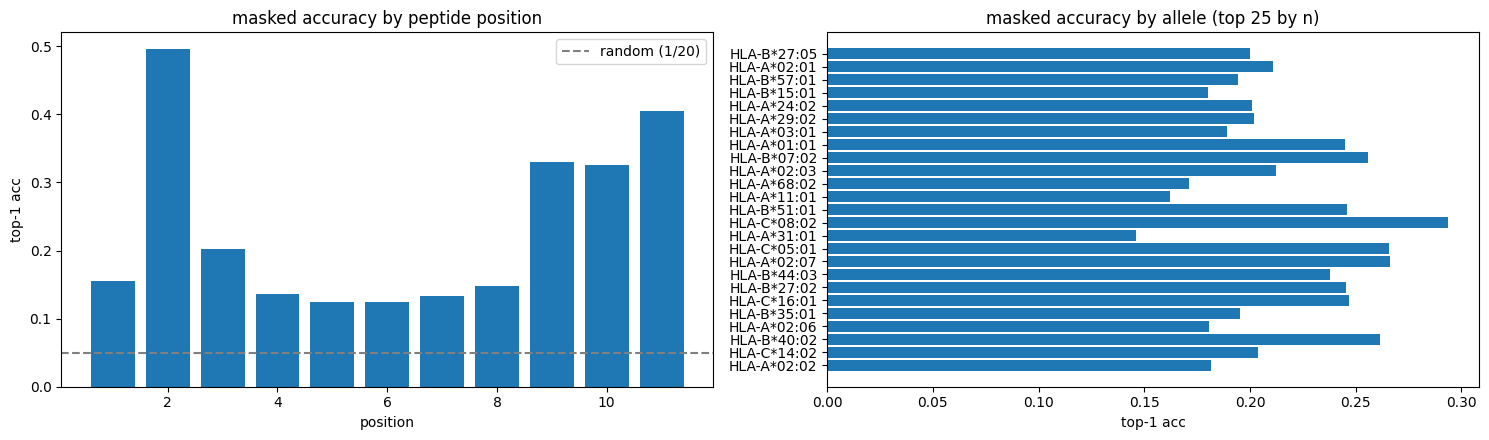

per-position:
 position      acc      n
        1 0.155929 201310
        2 0.495728 201310
        3 0.202732 201310
        4 0.135880 201310
        5 0.123710 201310
        6 0.123730 201310
        7 0.133178 201310
        8 0.148527 201310
        9 0.330020 191858
       10 0.325888  66216
       11 0.405644  20163

per-allele (top 10 by n):
     allele      acc      n
HLA-B*27:05 0.200027 275748
HLA-A*02:01 0.210858 140379
HLA-B*57:01 0.194544  93408
HLA-B*15:01 0.180205  68522
HLA-A*24:02 0.201116  64719
HLA-A*29:02 0.201773  59101
HLA-A*03:01 0.189360  55054
HLA-A*01:01 0.244798  52909
HLA-B*07:02 0.255661  46108
HLA-A*02:03 0.212453  42320


In [9]:
per_pos, per_al = masked_accuracy_breakdown(model, pep_seqs, mhc_esm, alleles=alleles)
per_pos.to_csv(f'{PRETRAIN_DIR}/pep_acc_per_position.csv', index=False)
per_al.to_csv(f'{PRETRAIN_DIR}/pep_acc_per_allele.csv', index=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].bar(per_pos.position, per_pos.acc)
ax[0].axhline(1/20, ls='--', c='gray', label='random (1/20)')
ax[0].set(title='masked accuracy by peptide position', xlabel='position', ylabel='top-1 acc')
ax[0].legend()
top = per_al[per_al.n >= 200].head(25)             # alleles with enough peptides
ax[1].barh(top.allele[::-1], top.acc[::-1])
ax[1].set(title='masked accuracy by allele (top 25 by n)', xlabel='top-1 acc')
plt.tight_layout()
plt.savefig(f'{PRETRAIN_DIR}/pep_acc_breakdown.png', dpi=150)
plt.show()

print('per-position:')
print(per_pos.to_string(index=False))
print('\nper-allele (top 10 by n):')
print(per_al.head(10).to_string(index=False))

## 4. Commit & push outputs

In [10]:
import json
# strip Colab widget metadata so GitHub can render the notebooks
for _nb in ['notebooks/pretrain_tcr.ipynb', 'notebooks/pretrain_peptide.ipynb']:
    _p = f'{REPO}/{_nb}'
    if os.path.exists(_p):
        _d = json.load(open(_p)); _d.get('metadata', {}).pop('widgets', None)
        for _c in _d.get('cells', []): _c.get('metadata', {}).pop('widgets', None)
        json.dump(_d, open(_p, 'w'), indent=1)
subprocess.run(['git', 'config', 'user.email', '92kunheekim@gmail.com'], cwd=REPO)
subprocess.run(['git', 'config', 'user.name', 'KH Kim'], cwd=REPO)
subprocess.run(['git', 'add', '-f', 'pretrained',
                'notebooks/pretrain_tcr.ipynb', 'notebooks/pretrain_peptide.ipynb'], cwd=REPO)
subprocess.run(['git', 'commit', '-m', 'Pretrained MHC-conditioned peptide transformer MLM (IEDB) [colab]'], cwd=REPO)
subprocess.run(['git', 'push', 'origin', 'main'], cwd=REPO, check=True)
print('pushed.')


pushed.


## Use in pan training
```python
import torch
from pan_specific import PanFusion
from train_utils import make_warm_start
pep_state = torch.load(f'{PRETRAIN_DIR}/pep_encoder_masked.pt')
mhc_state = torch.load(f'{PRETRAIN_DIR}/mhc_encoder_masked.pt')
warm = make_warm_start(TCR_ENC, pep_state=pep_state, mhc_state=mhc_state)
model = warm(PanFusion(use_pose=True, pep_arch='transformer'))   # pep_arch must match pretraining
```
The MHC ESM-2 embeddings here are built from the **α1α2 groove** — keep the pan model's
`esm_table` consistent (embed the same region) so the warm-started `mhc_encoder` sees the
same input distribution.